In [9]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_lfw_people
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras import layers, models

In [10]:
lfw = fetch_lfw_people(
    min_faces_per_person=50,
    resize=0.4,
    color=False
)

X = lfw.images
y = lfw.target
target_names = lfw.target_names

print("Images shape:", X.shape)
print("Number of classes:", len(target_names))
print("People/classes:", target_names)

Images shape: (1560, 50, 37)
Number of classes: 12
People/classes: ['Ariel Sharon' 'Colin Powell' 'Donald Rumsfeld' 'George W Bush'
 'Gerhard Schroeder' 'Hugo Chavez' 'Jacques Chirac' 'Jean Chretien'
 'John Ashcroft' 'Junichiro Koizumi' 'Serena Williams' 'Tony Blair']


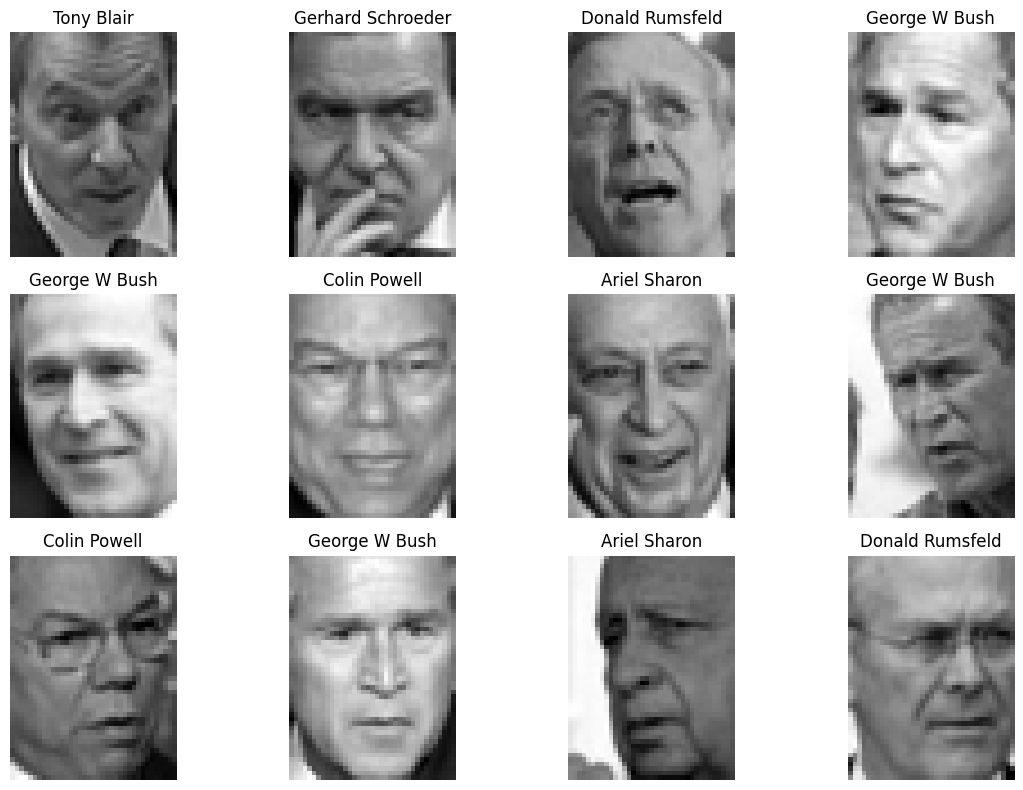

In [11]:
plt.figure(figsize=(12, 8))

for i in range(12):
    plt.subplot(3, 4, i + 1)
    plt.imshow(X[i], cmap="gray")
    plt.title(target_names[y[i]])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [12]:
X = X / 255.0

# Add channel dimension for CNN
X = X[..., np.newaxis]

print("New image shape:", X.shape)

New image shape: (1560, 50, 37, 1)


In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training images:", X_train.shape)
print("Testing images:", X_test.shape)

Training images: (1248, 50, 37, 1)
Testing images: (312, 50, 37, 1)


In [14]:
model = models.Sequential([
    layers.Input(shape=X_train.shape[1:]),

    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),

    layers.Dense(len(target_names), activation="softmax")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 48, 35, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 17, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 22, 15, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 11, 7, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 9, 5, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 12)             │         1,548 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,420 (880.55 KB)

 Trainable params: 225,420 (880.55 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [16]:
history = model.fit(
    X_train,
    y_train,
    epochs=15,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 83ms/step - accuracy: 0.3307 - loss: 2.2766 - val_accuracy: 0.3120 - val_loss: 2.2048
Epoch 2/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 73ms/step - accuracy: 0.3467 - loss: 2.1648 - val_accuracy: 0.3120 - val_loss: 2.1925
Epoch 3/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 88ms/step - accuracy: 0.3467 - loss: 2.1692 - val_accuracy: 0.3120 - val_loss: 2.1986
Epoch 4/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 101ms/step - accuracy: 0.3467 - loss: 2.1471 - val_accuracy: 0.3120 - val_loss: 2.2020
Epoch 5/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 72ms/step - accuracy: 0.3467 - loss: 2.1494 - val_accuracy: 0.3120 - val_loss: 2.2245
Epoch 6/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 77ms/step - accuracy: 0.3467 - loss: 2.1563 - val_accuracy: 0.3120 - val_loss: 2.2051
Epoch 7/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 73ms/step - accuracy: 0.3467 - loss: 2.1385 - val_accuracy: 0.3120 - val_loss: 2.2049
Epoch 8/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 94ms/step - accuracy: 0.3467 - loss: 2.1534 - val_accuracy: 0.3120 - 

In [17]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - accuracy: 0.3397 - loss: 2.1316
Test Loss: 2.131596803665161
Test Accuracy: 0.33974358439445496


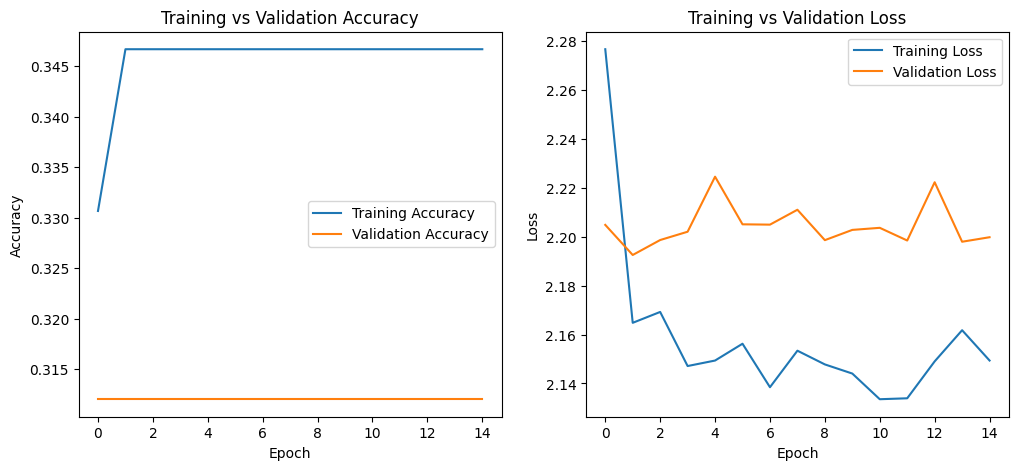

In [18]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Training vs Validation Accuracy")

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Training vs Validation Loss")

plt.show()

In [19]:
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

print(classification_report(
    y_test,
    y_pred_classes,
    target_names=target_names
))

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step
                   precision    recall  f1-score   support

     Ariel Sharon       0.00      0.00      0.00        16
     Colin Powell       0.00      0.00      0.00        47
  Donald Rumsfeld       0.00      0.00      0.00        24
    George W Bush       0.34      1.00      0.51       106
Gerhard Schroeder       0.00      0.00      0.00        22
      Hugo Chavez       0.00      0.00      0.00        14
   Jacques Chirac       0.00      0.00      0.00        10
    Jean Chretien       0.00      0.00      0.00        11
    John Ashcroft       0.00      0.00      0.00        11
Junichiro Koizumi       0.00      0.00      0.00        12
  Serena Williams       0.00      0.00      0.00        10
       Tony Blair       0.00      0.00      0.00        29

         accuracy                           0.34       312
        macro avg       0.03      0.08      0.04       312
     weighted avg       0.12      0.34      0.17       312



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


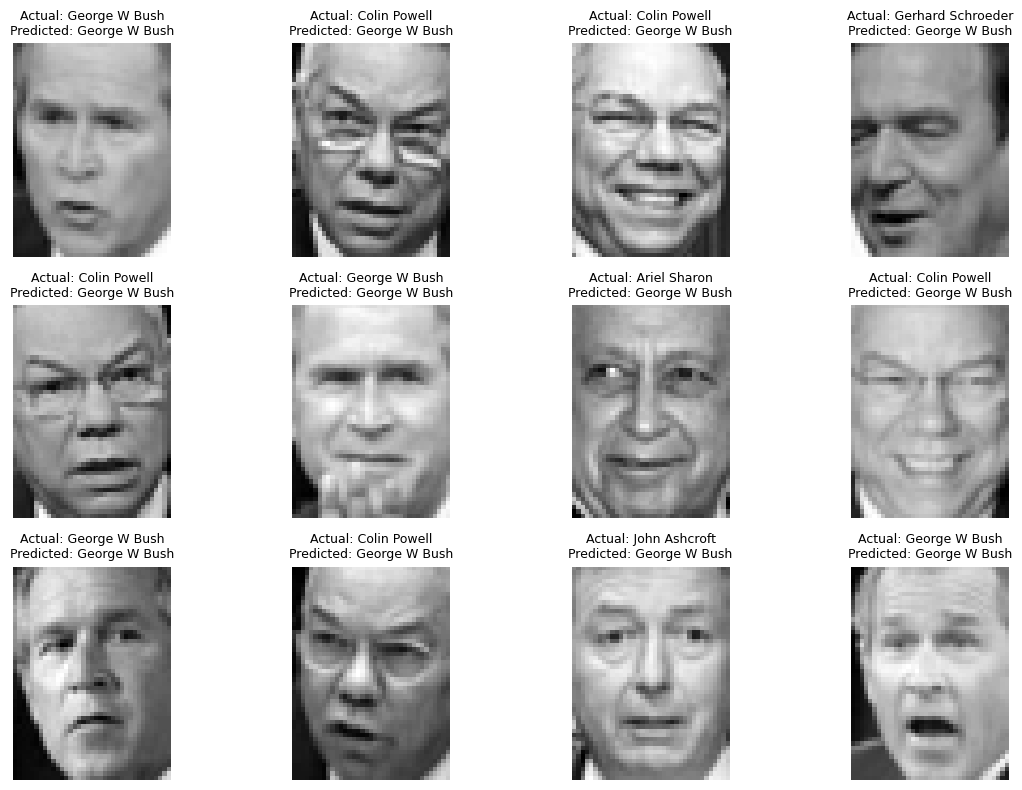

In [20]:
plt.figure(figsize=(12, 8))

for i in range(12):
    image = X_test[i]

    prediction = model.predict(
        np.expand_dims(image, axis=0),
        verbose=0
    )

    predicted_class = np.argmax(prediction)
    predicted_name = target_names[predicted_class]
    actual_name = target_names[y_test[i]]

    plt.subplot(3, 4, i + 1)
    plt.imshow(image.squeeze(), cmap="gray")
    plt.title(
        f"Actual: {actual_name}\nPredicted: {predicted_name}",
        fontsize=9
    )
    plt.axis("off")

plt.tight_layout()
plt.show()

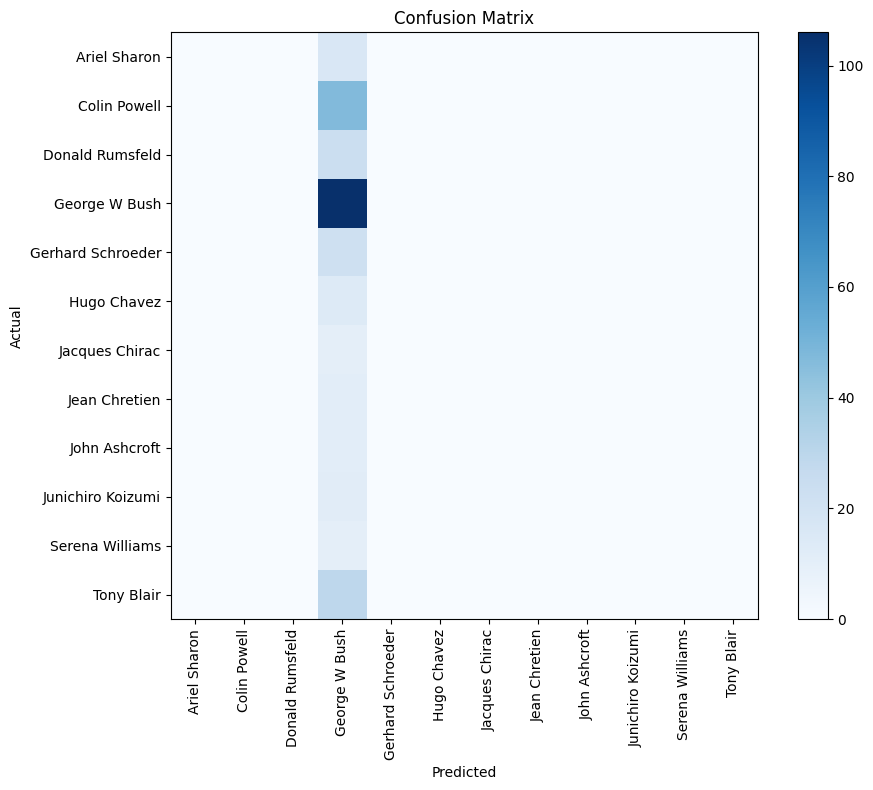

In [21]:
cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(10, 8))
plt.imshow(cm, cmap="Blues")
plt.colorbar()

plt.xticks(
    range(len(target_names)),
    target_names,
    rotation=90
)

plt.yticks(
    range(len(target_names)),
    target_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.tight_layout()
plt.show()

In [22]:
model.save("lfw_face_recognition_cnn.keras")

print("Model saved successfully!")

Model saved successfully!
